In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

train_val_dir = r"C:\Computer Vision Project\archive (2)\lung_colon_image_set\Train and Validation Set"

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [6]:
class OrganDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir)
        self.transform = transform
        self.samples = []

        for path, label in self.dataset.samples:
            class_name = self.dataset.classes[label]

            if "lung" in class_name:
                new_label = 0  # lung
            elif "colon" in class_name:
                new_label = 1  # colon
            else:
                continue

            self.samples.append((path, new_label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [7]:
full_dataset = OrganDataset(train_val_dir, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size]
)

val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train:", len(train_dataset), "Val:", len(val_dataset))

Train: 18000 Val: 4501


In [8]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 2)
)

model = model.to(device)

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

In [10]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS):
    best_acc = 0
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        correct = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)

        model.eval()
        val_correct = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                preds = torch.argmax(outputs, 1)
                val_correct += (preds == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train={train_acc:.4f}, Val={val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "organ_model.pth")

    return train_accs, val_accs

In [11]:
train_accs, val_accs = train_model(model, train_loader, val_loader)

Epoch 1: Train=0.9826, Val=0.9987
Epoch 2: Train=0.9932, Val=0.9987
Epoch 3: Train=0.9942, Val=0.9982
Epoch 4: Train=0.9955, Val=0.9993
Epoch 5: Train=0.9962, Val=0.9993
Epoch 6: Train=0.9950, Val=0.9998
Epoch 7: Train=0.9976, Val=1.0000
Epoch 8: Train=0.9966, Val=0.9991
Epoch 9: Train=0.9964, Val=0.9996
Epoch 10: Train=0.9977, Val=1.0000


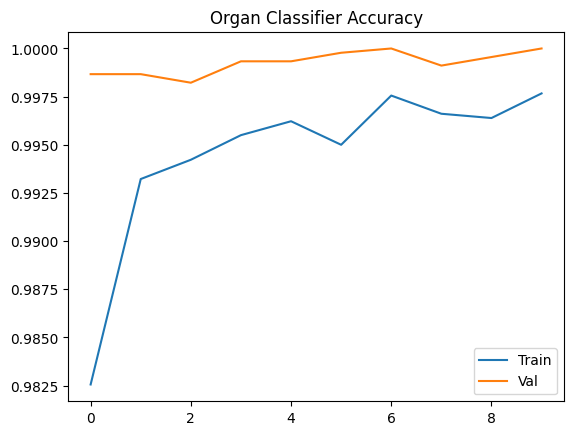

In [12]:
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Val")
plt.legend()
plt.title("Organ Classifier Accuracy")
plt.show()

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load("organ_model.pth"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        
        outputs = model(images)
        preds = torch.argmax(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Convert to numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# IMPORTANT: define class names EXACTLY 2
class_names = ["lung", "colon"]

print("===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1],   # FIXES mismatch issue
    target_names=class_names
))

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        lung       1.00      1.00      1.00      2652
       colon       1.00      1.00      1.00      1849

    accuracy                           1.00      4501
   macro avg       1.00      1.00      1.00      4501
weighted avg       1.00      1.00      1.00      4501



In [14]:
torch.save(model.state_dict(), "organ_model.pth")
print("✅ Organ model saved")

✅ Organ model saved


In [15]:
import json

class_mapping = {
    0: "lung",
    1: "colon"
}

with open("organ_class_mapping.json", "w") as f:
    json.dump(class_mapping, f)

print(" Class mapping saved")

 Class mapping saved


In [19]:
import numpy as np
import os
import matplotlib.pyplot as plt

def view_npy(file_path, show_plot=True):
    # Check file existence
    if not os.path.exists(file_path):
        print(f"File not found:\n{file_path}")
        return

    try:
        # Load file
        data = np.load(file_path, allow_pickle=True)

        print("\n File Loaded Successfully!\n")

        # Basic Info
        print("File Info:")
        print(f"Path        : {file_path}")
        print(f"Shape       : {data.shape}")
        print(f"Dtype       : {data.dtype}")
        print(f"Size        : {data.size}")

        # Handle scalar
        if data.shape == ():
            print("\n Scalar Value:")
            print(data.item())
            return

        # Preview
        print("\n Data Preview:")
        if data.ndim == 1:
            print(data[:10])
        elif data.ndim == 2:
            print(data[:5, :5])
        else:
            print(data.flatten()[:10])

        # Statistics (numeric only)
        if np.issubdtype(data.dtype, np.number):
            print("\n Statistics:")
            print(f"Min  : {np.min(data)}")
            print(f"Max  : {np.max(data)}")
            print(f"Mean : {np.mean(data):.4f}")
            print(f"Std  : {np.std(data):.4f}")

        # Plot (useful for signals like PPG, ECG)
        if show_plot and np.issubdtype(data.dtype, np.number):
            print("\n Plotting first sample...")

            plt.figure()

            if data.ndim == 1:
                plt.plot(data)
                plt.title("1D Signal")
            elif data.ndim == 2:
                plt.plot(data[0])  # first row/sample
                plt.title("First Sample (Row 0)")
            else:
                plt.plot(data.flatten()[:1000])
                plt.title("Flattened Data (First 1000 values)")

            plt.xlabel("Index")
            plt.ylabel("Value")
            plt.grid()
            plt.show()

    except Exception as e:
        print(f" Error loading file: {e}")


# =========================
# 🔹 GIVE YOUR FILE PATH HERE
# =========================
file_path = r"C:\Users\Harsh's PC\Desktop\Krish\LCD\colon_threshold.npy"

# Run viewer
view_npy(file_path)


 File Loaded Successfully!

File Info:
Path        : C:\Users\Harsh's PC\Desktop\Krish\LCD\colon_threshold.npy
Shape       : ()
Dtype       : float64
Size        : 1

 Scalar Value:
2550.4945362154403


In [20]:
test_dir = r"C:\Computer Vision Project\archive (2)\lung_colon_image_set\Test Set"

class OrganTestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir)
        self.transform = transform
        self.samples = []

        for path, label in self.dataset.samples:
            class_name = self.dataset.classes[label]

            if "lung" in class_name:
                new_label = 0
            elif "colon" in class_name:
                new_label = 1
            else:
                continue

            self.samples.append((path, new_label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [21]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [22]:
test_dataset = OrganTestDataset(test_dir, transform=test_transform)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test samples:", len(test_dataset))

Test samples: 2499


In [23]:
model.load_state_dict(torch.load("organ_model.pth", map_location=device))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = ["lung", "colon"]

print("===== TEST CLASSIFICATION REPORT =====")
print(classification_report(
    y_true,
    y_pred,
    labels=[0,1],
    target_names=class_names
))

===== TEST CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        lung       1.00      1.00      1.00      1499
       colon       1.00      1.00      1.00      1000

    accuracy                           1.00      2499
   macro avg       1.00      1.00      1.00      2499
weighted avg       1.00      1.00      1.00      2499



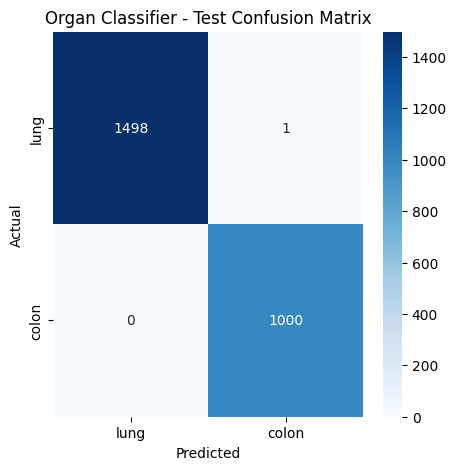

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Organ Classifier - Test Confusion Matrix")
plt.show()